In [45]:
import ee
import geemap
import numpy as np
from datetime import datetime, timedelta
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

import re
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio
from rasterio.windows import from_bounds
from pathlib import Path
from scipy.ndimage import uniform_filter
from scipy.stats import describe

# Initialize Earth Engine
ee.Authenticate()
ee.Initialize()

### Tracking dam construction overtime with Synthetic Aperture Radar (SAR) data

<b>SAR</b> was chosen because it operates at a microwave frequency (C-band) that penetrates clouds and rain, providing a continuous, <b>all-weather observation</b> record. Furthermore, SAR is highly sensitive to surface geometry and dielectric properties, allowing us to detect the "double-bounce" scattering effect characteristic of emerging vertical concrete structures and metal infrastructure, rather than just the visual footprint of cleared. <br><br>

For the analysis, we made some choices in terms of band and orbit selection:

- <b>SAR is a side-looking sensor.</b> If data from both Ascending (South to North) and Descending (North to South) orbits are mixed, the satellite views the target from opposite angles. In steep river valleys, this alternating geometry creates severe "sawtooth" noise in the time series due to changing radar layover and shadow effects. By restricting the data strictly to the Ascending pass, we locked the viewing angle, ensuring that any variation in backscatter intensity was caused by physical changes on the ground rather than changes in the sensor's perspective.

- Vertical transmit and Vertical receive (VV) polarization was selected over VH (Vertical-Horizontal) or cross-polarization. <b>VV is generally more sensitive to surface scattering and vertical geometries</b>, making it the optimal choice for detecting the hard, angular surfaces of dam walls, spillways, and heavy construction equipment.

<br>

Rather than analyzing individual satellite passes (which occur every 6 to 12 days), the time series was aggregated into Monthly Median Composites for two reasons:

- <b>Speckle and Transient Noise Reduction:</b> Raw SAR images contain inherent granular noise known as "speckle." Additionally, active construction sites feature transient high-reflectance targets (e.g., moving cranes, temporary scaffolding, or parked trucks). Taking the median value of all passes within a calendar month effectively filters out these temporary anomalies, leaving only the stable, permanent structural changes.

- <b>Computational Efficiency:</b> Aggregating to monthly medians drastically reduced the data volume, preventing memory timeouts during cloud-based processing while preserving the macro-level timeline of the multi-year construction project.
<br><br>

We're also considering a control point in the analysis (typically an upstream location in the river), to create a functional counter-signal to the dam construction. While the dam point monitors "building up," the reservoir point monitors "filling in," providing a complete picture of the project's operational status. We made the following assumptions:

- <b> [Detection of First Impoundment (Inverse Correlation)]</b>: 

    The primary reason to choose an upstream location is to detect the exact moment of First Impoundment (the start of reservoir filling).

    - <b>The Inverse Correlation: </b> In a successful project, you expect to see the Dam Wall backscatter stabilize at a high intensity (concrete/steel) while the Reservoir backscatter takes a sudden, permanent dive toward -20 dB or lower.

    - <b>Validation of Function:</b> High backscatter at the dam site proves the structure exists, but the drop at the reservoir site proves the structure is actually working to hold back water.

- <b> Monitoring Environmental Impact </b>:
    Choosing an upstream point allows you to measure the extent of the inundation zone.

    - Submergence Tracking: By placing a point in an area previously identified as forest or village (like Li Lu village near the Nam Tu site), you can verify when these areas are officially submerged.

     - Baseline Comparison: Comparing the upstream point to a "Forest Control" point helps distinguish between natural seasonal river fluctuations and the permanent water rise caused by the dam.

#### Common Functions

In [41]:
def process_dam_data(dam_coords, res_coords, start_date, end_date):
    """
    Analyses Sentinel-1 backscatter trends at dam and reservoir locations over a specified timeline.

    Args:
        dam_coords (list): [longitude, latitude] of the dam location.
        res_coords (list): [longitude, latitude] of the reservoir location.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        
    Returns:
        pd.DataFrame: A DataFrame containing mean backscatter values for the dam and reservoir locations
    """
    # Create FeatureCollection
    pts = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point(dam_coords).buffer(50), {'label': 'Dam'}),
        ee.Feature(ee.Geometry.Point(res_coords).buffer(40), {'label': 'Reservoir'})
    ])
    
    # Filter Sentinel-1 Collection
    s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(pts)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')) # Choosing only ascending to reduce 'sawtooth' effect
          .filter(ee.Filter.eq('instrumentMode', 'IW')))
    
    # Generate monthly composites with a "Band Check"
    months = ee.List.sequence(0, ee.Date(end_date).difference(ee.Date(start_date), 'month').round().subtract(1))
    
    def create_monthly(n):
        start = ee.Date(start_date).advance(n, 'month')
        end = start.advance(1, 'month')
        subset = s1_col.filterDate(start, end)
        count = subset.size()
        composite = subset.median()
        return composite.set({
            'system:time_start': start.millis(),
            'band_count': composite.bandNames().size()
        })
    
    monthly_col = (ee.ImageCollection.fromImages(months.map(create_monthly))
                   .filter(ee.Filter.gt('band_count', 0)))
    
    def extract_stats(image):
        date = image.date().format('YYYY-MM-dd')
        stats = image.reduceRegions(
            collection=pts,
            reducer=ee.Reducer.mean(),
            scale=10
        )
        return stats.map(lambda f: f.set('date', date))
    
    results = monthly_col.map(extract_stats).flatten().getInfo()
    data = [f['properties'] for f in results['features']]
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    
    return df

In [42]:
def postprocess_dam_data(df, label = 'dam'):
    #df = df.copy()

    if label.lower() == 'dam':
        df = df[df['label'] == 'Dam']
    elif label.lower() == 'reservoir':
        df = df[df['label'] == 'Reservoir']
    else:
        raise ValueError("Label must be either 'dam' or 'reservoir'")

    #df_dam = df[df['label'] == 'Dam']
    #df_res = df[df['label'] == 'Reservoir']

    ## Ensure the index is datetime and has a fixed monthly frequency
    df = df.sort_index()
    df['date'] = pd.to_datetime(df['date'])

    df = df.set_index('date')

    ## Resample the 'VV' values into monthly buckets (taking the mean of each month)
    df_monthly = df['VV'].resample('MS').mean().to_frame()

    ## Interpolating the series since models like STL require a continuous time series without missing values
    df['VV_filled'] = df['VV'].interpolate(method='linear')

    ## Modeling the time series using STL decomposition
    stl = STL(df['VV_filled'], period=12, seasonal=13, robust=True)
    res = stl.fit()

    ## Adding the components back to the dataframe for analysis
    df['trend'] = res.trend
    df['seasonal'] = res.seasonal
    df['deseasonalized'] = df['VV_filled'] - res.seasonal

    ## Check for nulls in the trend component
    print(f"Total NaNs in Trend: {df['trend'].isna().sum()}")   
    
    return df

In [43]:
def plot_trends(df, label):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    ax1.plot(df.index, df['VV'], color='gray', alpha=0.5, label='Original VV')
    ax1.plot(df.index, df['deseasonalized'], color='red', label='Deseasonalized (STL)')
    ax1.set_title(f'Original vs. Deseasonalized {label} Progress')
    ax1.legend()

    ax2.plot(df.index, df['trend'], color='blue')
    ax2.set_title('Trend Component (Long-term Structural Growth)')

    ax3.plot(df.index, df['seasonal'], color='green')
    ax3.set_title('Seasonal Component (Monsoon Cycles)')

    ax4.scatter(df.index, df['VV_filled'] - df['trend'] - df['seasonal'], color='black', s=10)
    ax4.set_title('Residuals (Unexplained Anomalies)')

    plt.tight_layout()
    plt.show()

#### Upper Yeywa Dam 

In [69]:
## Define coordinates for the dam and reservoir
dam_coords = [97.101855, 22.242240]
res_coords = [97.133449, 22.249188]

# Define the full timeline: Baseline (2014) to Present (Feb 2026)
start_date = '2014-01-01'
end_date = '2026-01-31'

df = process_dam_data(dam_coords, res_coords, start_date, end_date)

In [ ]:
df_dam = postprocess_dam_data(df, label='dam')

Total NaNs in Trend: 0


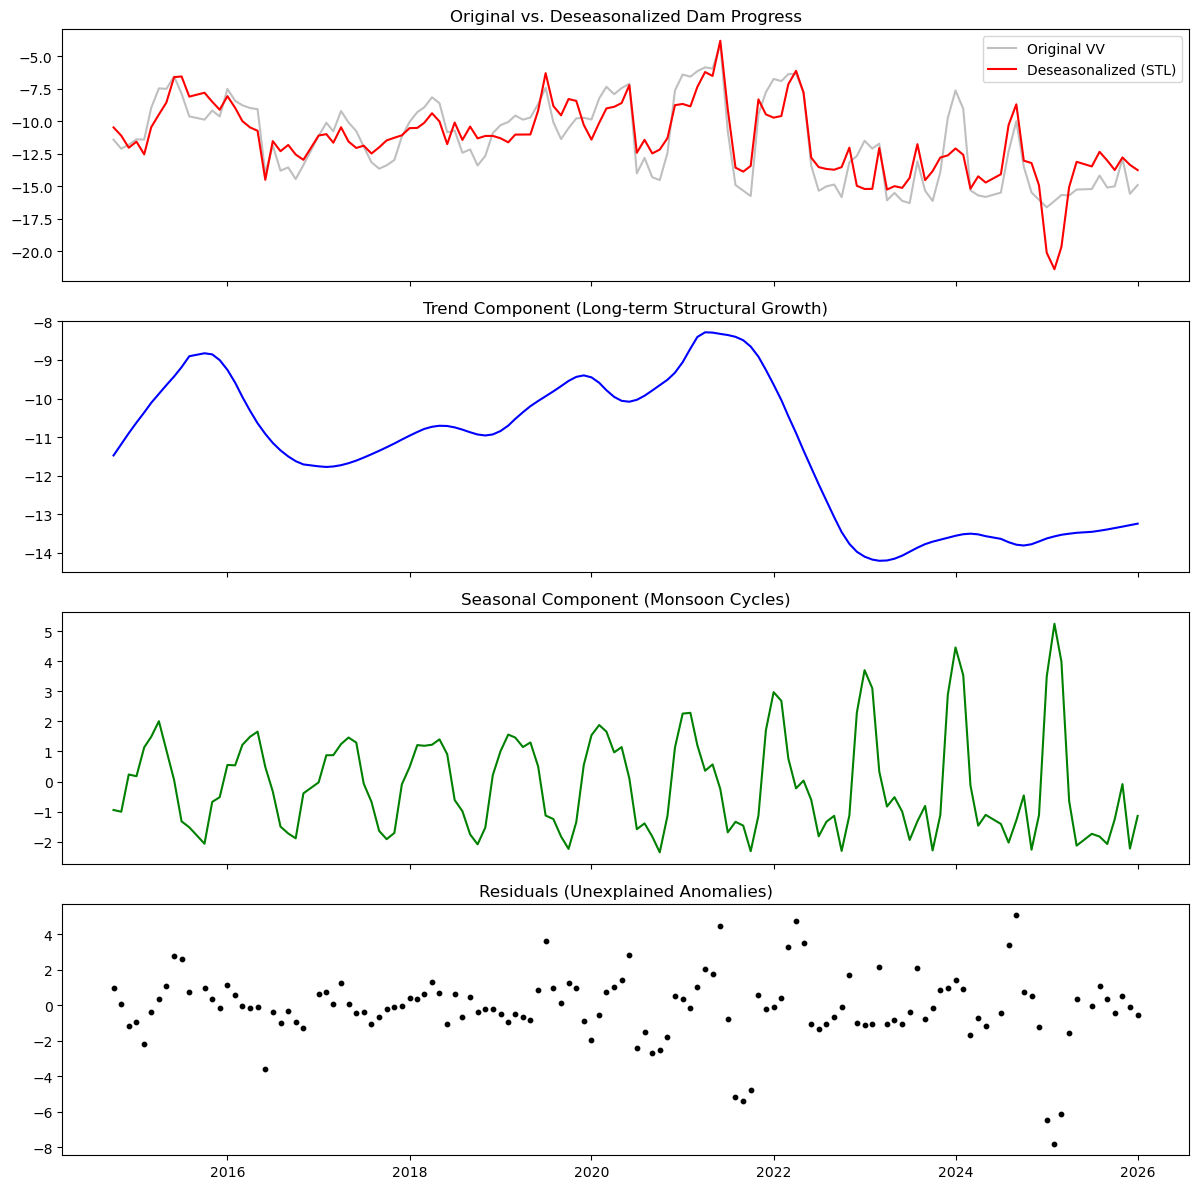

In [17]:
plot_trends(df_dam, label='Dam')

#### Nam Tu Project

In [61]:
dam_coords = [97.319400, 22.720900]
res_coords = [97.298971, 22.738562]

In [62]:
# Define the full timeline: Baseline (2014) to Present (Feb 2026)
start_date = '2014-01-01'
end_date = '2026-01-31'

df = process_dam_data(dam_coords, res_coords, start_date, end_date)

In [63]:
df_dam = postprocess_dam_data(df, label='dam')

Total NaNs in Trend: 0


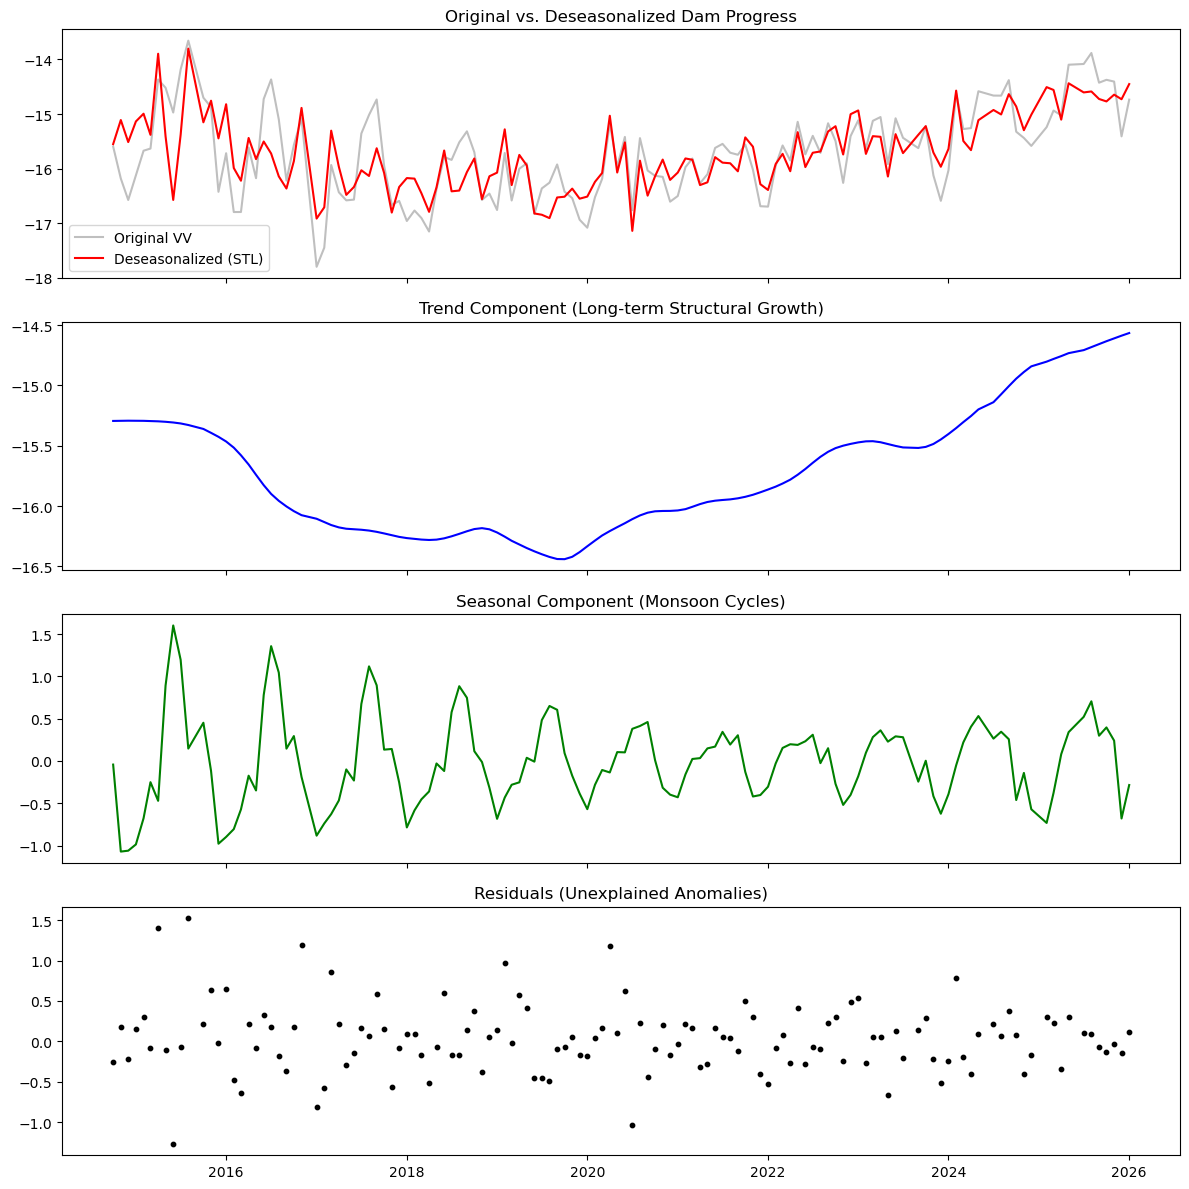

In [64]:
plot_trends(df_dam, label='Dam')

#### Upper Kengtawng Hydroelectric Plant

In [39]:
dam_coords = [98.1839, 20.7462]
res_coords = [98.167892, 20.724354]

In [46]:
# Define the full timeline: Baseline (2014) to Present (Feb 2026)
start_date = '2014-01-01'
end_date = '2026-01-31'

df = process_dam_data(dam_coords, res_coords, start_date, end_date)

In [47]:
df_dam = postprocess_dam_data(df, label='dam')

Total NaNs in Trend: 0


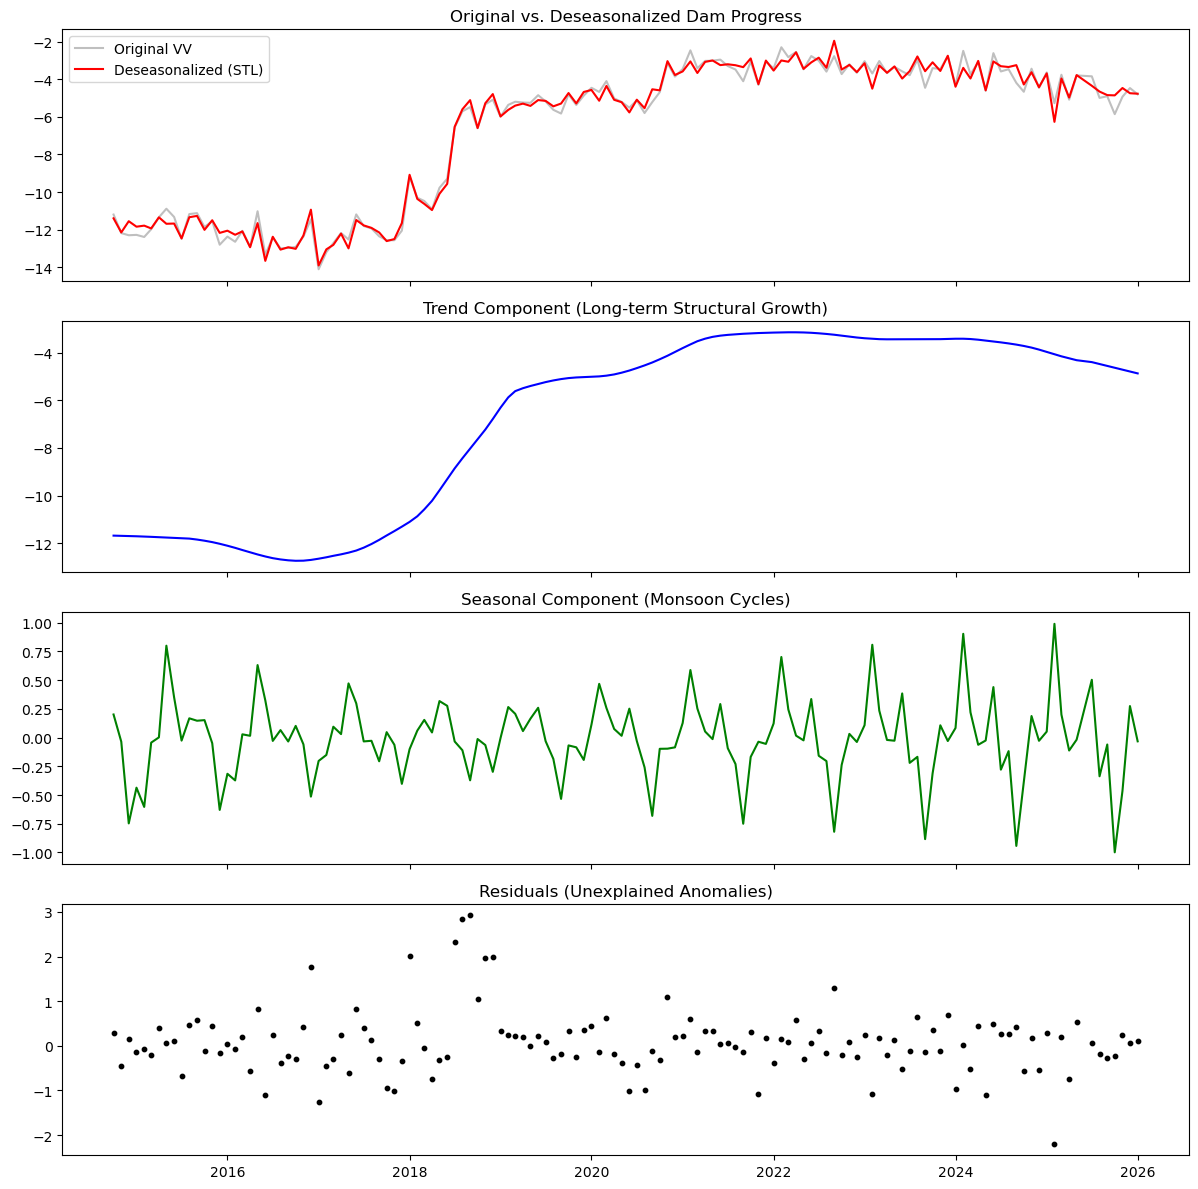

In [48]:
plot_trends(df_dam, label='Dam')

#### Mone Chaung Hydroelectric Plant

In [83]:
mc_coords = [94.259558, 20.476861]
mc_res_coords = [94.263602, 20.485256]

# Define the full timeline: Baseline (2014) to Present (Feb 2026)
start_date = '2018-01-01'
end_date = '2026-01-31'

df = process_dam_data(mc_coords, mc_res_coords, start_date, end_date)

In [84]:
df_dam = postprocess_dam_data(df, label='dam')

Total NaNs in Trend: 0


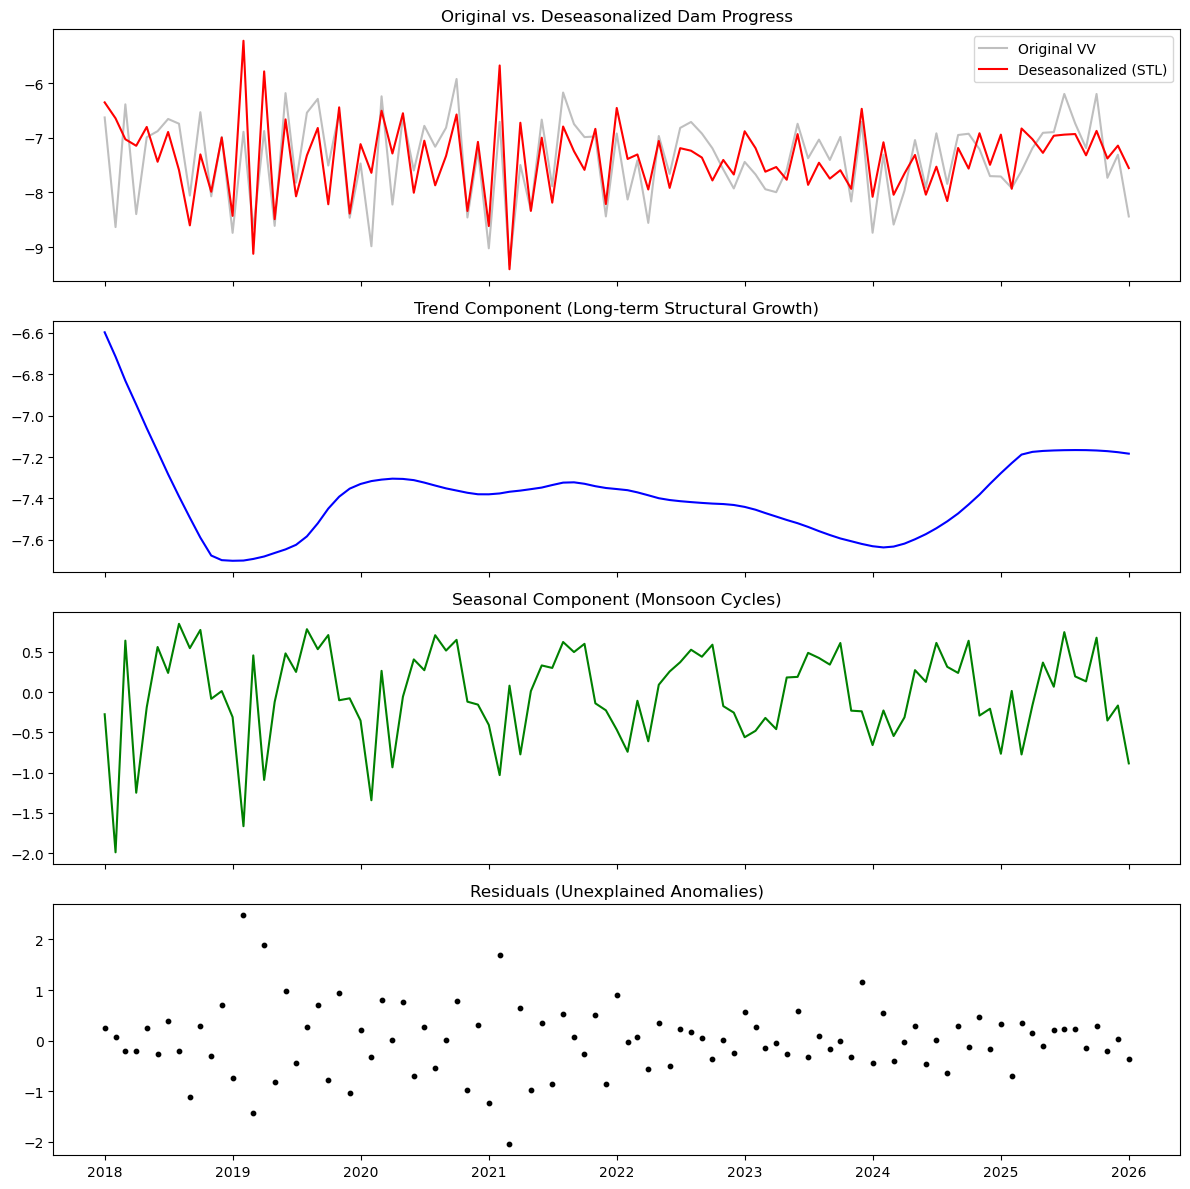

In [85]:
plot_trends(df_dam, label='Dam')

##### Coherenece Change Analysis

In [15]:
DATA_DIR = Path("/Users/gbhardwaj1/Library/CloudStorage/OneDrive-WBG/Documents/GitHub/myanmar-economic-monitor/data/SLC_CCL")   # ← Update to your data directory

FRAME    = "143A_06849_131313"

# Interferogram subdirectories
PAIRS = {
    "pre_seismic" : {"dir": "pre_seismic",  "dates": "20250315_20250327",
                     "label": "Pre-seismic\n(Mar 15→27)"},
    "coseismic"   : {"dir": "coseismic",    "dates": "20250315_20250402",
                     "label": "Coseismic\n(Mar 15→Apr 2)"},
    "post_seismic": {"dir": "post_seismic", "dates": "20250402_20250408",
                     "label": "Post-seismic\n(Apr 2→8)"},
}

In [30]:
DAM_LON =  94.259903
DAM_LAT =  20.478216

# Analysis buffer around dam (degrees) — ~5 km box
BUFFER = 0.02

# Sentinel-1 C-band wavelength
WAVELENGTH_CM = 5.6

# Coherence threshold for reliable pixels
COH_THRESHOLD = 0.35

# LOS conversion: 1 full 2π cycle = λ/2 LOS displacement
LOS_PER_RADIAN_CM = WAVELENGTH_CM / (4 * np.pi)   # ~0.446 cm/rad

In [4]:
# ─────────────────────────────────────────────────────────────
# 1. FILE PATH HELPERS
# ─────────────────────────────────────────────────────────────

def frame_file(suffix):
    """Path to a frame-level file (LOS vectors, DEM, landmask)."""
    return DATA_DIR / f"{FRAME}.{suffix}"

def pair_file(pair_key, suffix):
    """Path to an interferogram-level file for a given pair."""
    p = PAIRS[pair_key]
    return DATA_DIR / p["dir"] / f"{p['dates']}.{suffix}"

In [5]:
# ─────────────────────────────────────────────────────────────
# 1. FILE PATH HELPERS
# ─────────────────────────────────────────────────────────────

def frame_file(suffix):
    """Path to a frame-level file (LOS vectors, DEM, landmask)."""
    return DATA_DIR / f"{FRAME}.{suffix}"

def pair_file(pair_key, suffix):
    """Path to an interferogram-level file for a given pair."""
    p = PAIRS[pair_key]
    return DATA_DIR / p["dir"] / f"{p['dates']}.{suffix}"

# ─────────────────────────────────────────────────────────────
# 2. RASTER I/O
# ─────────────────────────────────────────────────────────────

def read_raster(path, aoi_bounds=None):
    """
    Read a GeoTIFF, optionally clipping to AOI bounds.
    Returns (data, transform, crs, nodata).
    Nodata and zero-fill pixels are masked.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with rasterio.open(path) as src:
        if aoi_bounds:
            window = from_bounds(*aoi_bounds, transform=src.transform)
            data   = src.read(1, window=window)
            transform = src.window_transform(window)
        else:
            data      = src.read(1)
            transform = src.transform
        nodata = src.nodata
        crs    = src.crs

    data = data.astype(np.float32)

    # Mask nodata and sentinel zero values
    mask = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        mask |= (data == nodata)
    mask |= ~np.isfinite(data)

    data = np.ma.masked_where(mask, data)
    return data, transform, crs, nodata


def get_aoi_bounds():
    """AOI bounding box around Mone Chaung Dam."""
    return (
        DAM_LON - BUFFER,   # left
        DAM_LAT - BUFFER,   # bottom
        DAM_LON + BUFFER,   # right
        DAM_LAT + BUFFER,   # top
    )


def raster_extent(transform, shape):
    """Compute [left, right, bottom, top] extent for imshow."""
    rows, cols = shape
    left   = transform.c
    right  = transform.c + transform.a * cols
    top    = transform.f
    bottom = transform.f + transform.e * rows
    return [left, right, bottom, top]

In [6]:
# ─────────────────────────────────────────────────────────────
# 2. RASTER I/O
# ─────────────────────────────────────────────────────────────

def read_raster(path, aoi_bounds=None):
    """
    Read a GeoTIFF, optionally clipping to AOI bounds.
    Returns (data, transform, crs, nodata).
    Nodata and zero-fill pixels are masked.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with rasterio.open(path) as src:
        if aoi_bounds:
            window = from_bounds(*aoi_bounds, transform=src.transform)
            data   = src.read(1, window=window)
            transform = src.window_transform(window)
        else:
            data      = src.read(1)
            transform = src.transform
        nodata = src.nodata
        crs    = src.crs

    data = data.astype(np.float32)

    # Mask nodata and sentinel zero values
    mask = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        mask |= (data == nodata)
    mask |= ~np.isfinite(data)

    data = np.ma.masked_where(mask, data)
    return data, transform, crs, nodata


def get_aoi_bounds():
    """AOI bounding box around Mone Chaung Dam."""
    return (
        DAM_LON - BUFFER,   # left
        DAM_LAT - BUFFER,   # bottom
        DAM_LON + BUFFER,   # right
        DAM_LAT + BUFFER,   # top
    )


def raster_extent(transform, shape):
    """Compute [left, right, bottom, top] extent for imshow."""
    rows, cols = shape
    left   = transform.c
    right  = transform.c + transform.a * cols
    top    = transform.f
    bottom = transform.f + transform.e * rows
    return [left, right, bottom, top]

In [7]:
# ─────────────────────────────────────────────────────────────
# 3. METADATA PARSING
# ─────────────────────────────────────────────────────────────

def parse_metadata():
    """
    Parse LiCSAR metadata.txt for key parameters.
    Returns dict with heading, incidence, wavelength etc.
    """
    meta_path = DATA_DIR / "metadata.txt"
    meta = {}

    if not meta_path.exists():
        print("⚠ metadata.txt not found — using Sentinel-1 defaults")
        return {
            "heading_deg"  : -169.0,   # Typical S1 ascending heading
            "incidence_deg":   39.0,   # Typical S1 IW mid-swath
            "wavelength_cm":    5.6,
        }

    with open(meta_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            # LiCSAR metadata format: KEY = VALUE or KEY: VALUE
            for sep in ["=", ":"]:
                if sep in line:
                    key, _, val = line.partition(sep)
                    meta[key.strip().lower()] = val.strip()
                    break

    # Extract numeric values with fallbacks
    def get_float(keys, default):
        for k in keys:
            if k in meta:
                try:
                    return float(re.sub(r"[^\d.\-]", "", meta[k]))
                except ValueError:
                    pass
        return default

    result = {
        "heading_deg"  : get_float(["heading", "sat_heading"], -169.0),
        "incidence_deg": get_float(["incidence_angle", "inc_angle", "incidence"], 39.0),
        "wavelength_cm": get_float(["wavelength", "lambda"], 5.6),
    }

    print(f"  Heading angle  : {result['heading_deg']:.1f}°")
    print(f"  Incidence angle: {result['incidence_deg']:.1f}°")
    print(f"  Wavelength     : {result['wavelength_cm']:.2f} cm")
    return result


def parse_baselines():
    """Parse baselines.txt — temporal and perpendicular baselines per pair."""
    bl_path = DATA_DIR / "baselines.txt"
    baselines = {}

    if not bl_path.exists():
        return baselines

    with open(bl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                pair = parts[0]
                try:
                    bperp  = float(parts[1])
                    btemp  = float(parts[2])
                    baselines[pair] = {"bperp_m": bperp, "btemp_days": btemp}
                except ValueError:
                    pass
    return baselines

In [8]:
# ─────────────────────────────────────────────────────────────
# 4. LOS → DISPLACEMENT CONVERSION
# ─────────────────────────────────────────────────────────────

def los_to_vertical_horizontal(unw_phase, U_los, E_los, N_los, wavelength_cm):
    """
    Convert unwrapped LOS phase to vertical and horizontal displacement.

    LOS displacement (cm) = (wavelength / 4π) × unwrapped_phase
    Then project onto vertical using LOS unit vector U component.

    For single-geometry InSAR, we can only isolate vertical if we
    assume horizontal motion is negligible (valid near dam structure
    on non-fault pixels). For fault-crossing pixels, this underestimates.

    Parameters:
        unw_phase   : unwrapped phase (radians)
        U_los       : Up component of LOS unit vector
        E_los       : East component of LOS unit vector
        N_los       : North component of LOS unit vector
        wavelength_cm: radar wavelength in cm

    Returns:
        los_cm      : LOS displacement in cm
        vert_cm     : Approximate vertical displacement (cm)
    """
    scale = wavelength_cm / (4 * np.pi)

    # LOS displacement — positive = motion toward satellite
    los_cm = unw_phase * scale

    # Vertical component approximation
    # d_LOS = U*d_up + E*d_east + N*d_north
    # Assuming d_east ≈ d_north ≈ 0 (valid for subsidence/uplift dominated signal)
    # d_up ≈ d_LOS / U_component
    with np.errstate(divide="ignore", invalid="ignore"):
        vert_cm = np.ma.where(
            np.abs(U_los) > 0.1,
            los_cm / U_los,
            np.ma.masked
        )

    return los_cm, vert_cm

In [9]:
# ─────────────────────────────────────────────────────────────
# 5. COHERENCE ANALYSIS
# ─────────────────────────────────────────────────────────────

def classify_coherence(coh):
    """
    Classify coherence into disturbance zones.

    For dam monitoring post-earthquake:
      High   (>0.6) : Stable hard surface — no significant change
      Medium (0.35–0.6): Moderate change — possible minor disturbance
      Low    (<0.35): Strong decorrelation — water, damage, construction
    """
    stable    = coh > 0.6
    moderate  = (coh >= COH_THRESHOLD) & (coh <= 0.6)
    disturbed = coh < COH_THRESHOLD

    total = coh.count()  # masked array — count valid pixels only
    stats = {
        "stable_pct"   : 100 * stable.sum()    / total,
        "moderate_pct" : 100 * moderate.sum()  / total,
        "disturbed_pct": 100 * disturbed.sum() / total,
        "mean_coh"     : float(np.ma.mean(coh)),
        "zone_map"     : np.ma.where(stable, 3,
                         np.ma.where(moderate, 2,
                         np.ma.where(disturbed, 1, np.ma.masked))),
    }
    return stats


def coherence_change(coh_pre, coh_coseis):
    """
    Compute coherence loss between pre-seismic and coseismic pairs.
    Negative values = coherence loss = disturbance.
    """
    return coh_coseis - coh_pre

In [10]:
# ─────────────────────────────────────────────────────────────
# 6. DAM ROI STATISTICS
# ─────────────────────────────────────────────────────────────

def extract_dam_roi_stats(data, transform, radius_deg=0.02, label=""):
    """
    Extract statistics within a circular ROI around the dam.
    radius_deg ≈ 2.2 km at Myanmar latitudes.
    """
    rows, cols = data.shape
    lons = transform.c + transform.a * np.arange(cols)
    lats = transform.f + transform.e * np.arange(rows)
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    dist = np.sqrt((lon_grid - DAM_LON)**2 + (lat_grid - DAM_LAT)**2)
    roi  = (dist < radius_deg) & ~data.mask if np.ma.is_masked(data) else dist < radius_deg

    roi_data = data[roi]
    if roi_data.size == 0:
        print(f"  ⚠ No valid pixels in dam ROI for {label}")
        return {}

    stats = {
        "mean"  : float(np.nanmean(roi_data)),
        "std"   : float(np.nanstd(roi_data)),
        "min"   : float(np.nanmin(roi_data)),
        "max"   : float(np.nanmax(roi_data)),
        "n_px"  : int(roi_data.size),
    }

    print(f"\n  Dam ROI stats — {label}:")
    print(f"    Pixels     : {stats['n_px']}")
    print(f"    Mean       : {stats['mean']:+.3f}")
    print(f"    Std        : {stats['std']:.3f}")
    print(f"    Range      : {stats['min']:+.3f} to {stats['max']:+.3f}")
    return stats


In [11]:
# ─────────────────────────────────────────────────────────────
# 7. VISUALIZATION
# ─────────────────────────────────────────────────────────────

def add_dam_marker(ax, label=True):
    """Add dam location marker to axis."""
    ax.plot(DAM_LON, DAM_LAT, "w^", markersize=9,
            markeredgecolor="k", markeredgewidth=1.2, zorder=10)
    if label:
        ax.annotate("Mone Chaung Dam",
                    xy=(DAM_LON, DAM_LAT),
                    xytext=(5, 6), textcoords="offset points",
                    color="white", fontsize=7,
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc="black", alpha=0.5, ec="none"))


def plot_wrapped_phase_triplet(aoi_bounds):
    """
    Panel 1: Wrapped interferometric phase for all three pairs.
    Each 2π fringe cycle = 2.8 cm LOS displacement.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Mone Chaung Dam — Wrapped Interferometric Phase\n"
        "Sentinel-1 Track 143A | 28 March 2025 M7.7 Earthquake",
        fontsize=13, fontweight="bold", y=1.01
    )

    for ax, (key, info) in zip(axes, PAIRS.items()):
        try:
            pha, transform, _, _ = read_raster(
                pair_file(key, "geo.diff_pha.tif"), aoi_bounds)
            extent = raster_extent(transform, pha.shape)

            im = ax.imshow(pha, cmap="hsv",
                           vmin=-np.pi, vmax=np.pi,
                           extent=extent, origin="upper",
                           interpolation="nearest")
            plt.colorbar(im, ax=ax, label="Phase (rad)",
                         fraction=0.046, pad=0.04)
            add_dam_marker(ax)
            ax.set_title(info["label"], fontsize=11, fontweight="bold")
            ax.set_xlabel("Longitude (°E)")
            ax.set_ylabel("Latitude (°N)")
            ax.set_xlim(aoi_bounds[0], aoi_bounds[2])
            ax.set_ylim(aoi_bounds[1], aoi_bounds[3])

            # Fringe density annotation
            grad = np.gradient(pha.filled(0))
            fringe_density = np.sqrt(grad[0]**2 + grad[1]**2).mean()
            ax.text(0.03, 0.04,
                    f"Fringe density: {fringe_density:.2f} rad/px",
                    transform=ax.transAxes, color="white", fontsize=7,
                    bbox=dict(fc="black", alpha=0.5, ec="none"))
        except FileNotFoundError as e:
            ax.text(0.5, 0.5, f"File not found:\n{e.filename}",
                    ha="center", va="center", transform=ax.transAxes,
                    color="red", fontsize=8)
            ax.set_title(info["label"])

    plt.tight_layout()
    out = DATA_DIR / "01_wrapped_phase_triplet.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: {out}")
    plt.show()


def plot_displacement_and_coherence(aoi_bounds, meta):
    """
    Panel 2: Unwrapped displacement + coherence for coseismic pair.
    This is the primary earthquake impact panel.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(
        "Mone Chaung Dam — Coseismic Displacement & Coherence Analysis\n"
        "20250315→20250402 | Earthquake: 28 March 2025",
        fontsize=13, fontweight="bold"
    )

    # Load LOS unit vectors (frame-level, same for all pairs)
    try:
        U_los, tf_u, _, _ = read_raster(frame_file("geo.U.tif"), aoi_bounds)
        E_los, _,    _, _ = read_raster(frame_file("geo.E.tif"), aoi_bounds)
        N_los, _,    _, _ = read_raster(frame_file("geo.N.tif"), aoi_bounds)
        has_los_vectors = True
    except FileNotFoundError:
        print("⚠ LOS unit vector files not found — skipping vertical decomposition")
        has_los_vectors = False

    # Load landmask
    try:
        landmask, _, _, _ = read_raster(frame_file("geo.landmask.tif"), aoi_bounds)
        landmask = landmask.filled(0).astype(bool)
    except FileNotFoundError:
        landmask = None

    # Load DEM for context
    try:
        dem, tf_dem, _, _ = read_raster(frame_file("geo.hgt.tif"), aoi_bounds)
        has_dem = True
    except FileNotFoundError:
        has_dem = False

    pair_data = {}
    for key in PAIRS:
        try:
            unw, tf, _, _  = read_raster(pair_file(key, "geo.unw.tif"), aoi_bounds)
            coh, _,  _, _  = read_raster(pair_file(key, "geo.cc.tif"),  aoi_bounds)

            # Apply coherence mask to unwrapped phase
            unw = np.ma.masked_where(coh < COH_THRESHOLD, unw)

            # Apply landmask (mask water — reservoir surface is unreliable)
            if landmask is not None:
                unw = np.ma.masked_where(~landmask, unw)
                coh = np.ma.masked_where(~landmask, coh)

            pair_data[key] = {"unw": unw, "coh": coh, "transform": tf}
        except FileNotFoundError as e:
            print(f"⚠ Missing: {e.filename}")
            pair_data[key] = None

    # ── Row 1: LOS Displacement (unwrapped phase → cm) ──────────────────────
    for col, (key, info) in enumerate(PAIRS.items()):
        ax = axes[0, col]
        if pair_data[key] is None:
            ax.set_title(f"{info['label']}\n(data missing)")
            continue

        unw = pair_data[key]["unw"]
        tf  = pair_data[key]["transform"]
        extent = raster_extent(tf, unw.shape)

        # Convert to LOS displacement in cm
        los_cm = unw * LOS_PER_RADIAN_CM

        # Symmetric colorscale centered on zero
        vlim = np.nanpercentile(np.abs(los_cm.compressed()), 95) if los_cm.count() > 0 else 5
        vlim = max(vlim, 1.0)

        im = ax.imshow(los_cm, cmap="RdBu_r",
                       vmin=-vlim, vmax=vlim,
                       extent=extent, origin="upper",
                       interpolation="nearest")
        plt.colorbar(im, ax=ax, label="LOS displacement (cm)",
                     fraction=0.046, pad=0.04)

        # DEM contours for topographic context
        if has_dem:
            dem_ext = raster_extent(tf_dem, dem.shape)
            try:
                ax.contour(dem.filled(np.nan),
                           levels=8, colors="gray", alpha=0.3,
                           linewidths=0.5,
                           extent=dem_ext, origin="upper")
            except Exception:
                pass

        add_dam_marker(ax)
        ax.set_title(f"LOS Displacement\n{info['label']}", fontsize=10)
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)" if col == 0 else "")

        # Dam ROI stats
        extract_dam_roi_stats(los_cm, tf, label=f"LOS displacement — {key}")

    # ── Row 2: Coherence maps ────────────────────────────────────────────────
    for col, (key, info) in enumerate(PAIRS.items()):
        ax = axes[1, col]
        if pair_data[key] is None:
            ax.set_title(f"{info['label']}\n(data missing)")
            continue

        coh    = pair_data[key]["coh"]
        tf     = pair_data[key]["transform"]
        extent = raster_extent(tf, coh.shape)

        im = ax.imshow(coh, cmap="RdYlGn",
                       vmin=0, vmax=1,
                       extent=extent, origin="upper",
                       interpolation="nearest")
        plt.colorbar(im, ax=ax, label="Coherence",
                     fraction=0.046, pad=0.04)

        # Coherence threshold contour
        try:
            ax.contour(coh.filled(0),
                       levels=[COH_THRESHOLD],
                       colors=["blue"], linewidths=1.2,
                       extent=extent, origin="upper",
                       linestyles="--")
        except Exception:
            pass

        add_dam_marker(ax)
        ax.set_title(f"Coherence (coh ≥ {COH_THRESHOLD} = reliable)\n{info['label']}",
                     fontsize=10)
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)" if col == 0 else "")

        # Print coherence zone stats
        coh_stats = classify_coherence(coh)
        print(f"\n  Coherence zones — {key}:")
        print(f"    Stable    (>0.6) : {coh_stats['stable_pct']:.1f}%")
        print(f"    Moderate (0.35–0.6): {coh_stats['moderate_pct']:.1f}%")
        print(f"    Disturbed (<0.35): {coh_stats['disturbed_pct']:.1f}%")
        print(f"    Mean coherence   : {coh_stats['mean_coh']:.3f}")

    plt.tight_layout()
    out = DATA_DIR / "02_displacement_coherence.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\n✓ Saved: {out}")
    plt.show()

    return pair_data


def plot_coherence_disturbance_map(pair_data, aoi_bounds):
    """
    Panel 3: Coherence change map — pre vs coseismic.
    Highlights pixels that decorrelated due to earthquake.
    """
    if pair_data.get("pre_seismic") is None or pair_data.get("coseismic") is None:
        print("⚠ Cannot compute coherence change — missing pair data")
        return

    coh_pre    = pair_data["pre_seismic"]["coh"]
    coh_coseis = pair_data["coseismic"]["coh"]
    tf         = pair_data["coseismic"]["transform"]
    extent     = raster_extent(tf, coh_coseis.shape)

    # Regrid pre to coseismic grid if shapes differ
    if coh_pre.shape != coh_coseis.shape:
        from scipy.ndimage import zoom
        zoom_factors = (coh_coseis.shape[0] / coh_pre.shape[0],
                        coh_coseis.shape[1] / coh_pre.shape[1])
        coh_pre_data = zoom(coh_pre.filled(np.nan), zoom_factors, order=1)
        coh_pre = np.ma.masked_invalid(coh_pre_data)

    delta_coh = coherence_change(coh_pre, coh_coseis)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Mone Chaung Dam — Coherence Disturbance Map\n"
        "Earthquake-induced decorrelation as proxy for surface disturbance",
        fontsize=13, fontweight="bold"
    )

    # ── Left: Pre-seismic coherence ──────────────────────────────────────────
    ax = axes[0]
    im = ax.imshow(coh_pre, cmap="RdYlGn", vmin=0, vmax=1,
                   extent=extent, origin="upper")
    plt.colorbar(im, ax=ax, label="Coherence", fraction=0.046, pad=0.04)
    add_dam_marker(ax)
    ax.set_title("Pre-seismic Coherence\n(Mar 15→27)", fontsize=11)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

    # ── Centre: Coseismic coherence ──────────────────────────────────────────
    ax = axes[1]
    im = ax.imshow(coh_coseis, cmap="RdYlGn", vmin=0, vmax=1,
                   extent=extent, origin="upper")
    plt.colorbar(im, ax=ax, label="Coherence", fraction=0.046, pad=0.04)
    add_dam_marker(ax)
    ax.set_title("Coseismic Coherence\n(Mar 15→Apr 2)", fontsize=11)
    ax.set_xlabel("Longitude (°E)")

    # ── Right: Coherence change (delta) ─────────────────────────────────────
    ax = axes[2]
    vlim = 0.5
    im = ax.imshow(delta_coh, cmap="RdBu",
                   vmin=-vlim, vmax=vlim,
                   extent=extent, origin="upper")
    cbar = plt.colorbar(im, ax=ax, label="Δ Coherence (coseis − pre)",
                        fraction=0.046, pad=0.04)

    # Annotate strong decorrelation zones
    strong_loss = delta_coh < -0.3
    if strong_loss.any():
        ax.contour(strong_loss.filled(0).astype(float),
                   levels=[0.5], colors=["red"], linewidths=1.5,
                   extent=extent, origin="upper")

    add_dam_marker(ax)
    ax.set_title(
        "Coherence Change (Coseismic − Pre)\n"
        "Red = decorrelation (disturbance) | Blue = coherence gain",
        fontsize=10
    )
    ax.set_xlabel("Longitude (°E)")

    # Interpretation legend
    patches = [
        mpatches.Patch(color="red",   label="Strong loss (<−0.3): Damage / disturbance"),
        mpatches.Patch(color="#FF9999", label="Moderate loss: Vegetation / soil change"),
        mpatches.Patch(color="#9999FF", label="Coherence gain: Surface stabilisation"),
    ]
    ax.legend(handles=patches, loc="lower left", fontsize=7,
              framealpha=0.8)

    plt.tight_layout()
    out = DATA_DIR / "03_coherence_disturbance.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: {out}")
    plt.show()

    # Dam ROI coherence change stats
    extract_dam_roi_stats(delta_coh, tf, label="Coherence change at dam")


def plot_vertical_displacement(pair_data, aoi_bounds):
    """
    Panel 4: Approximate vertical displacement at dam site.
    Uses LOS unit vector U component for projection.
    Coseismic pair only — most physically meaningful.
    """
    if pair_data.get("coseismic") is None:
        print("⚠ No coseismic data for vertical displacement plot")
        return

    try:
        U_los, tf_u, _, _ = read_raster(frame_file("geo.U.tif"), aoi_bounds)
        E_los, _,    _, _ = read_raster(frame_file("geo.E.tif"), aoi_bounds)
        N_los, _,    _, _ = read_raster(frame_file("geo.N.tif"), aoi_bounds)
    except FileNotFoundError:
        print("⚠ LOS unit vectors not found — skipping vertical displacement panel")
        return

    unw = pair_data["coseismic"]["unw"]
    tf  = pair_data["coseismic"]["transform"]

    # Regrid LOS vectors to match unwrapped phase grid if needed
    if U_los.shape != unw.shape:
        from scipy.ndimage import zoom
        zf = (unw.shape[0] / U_los.shape[0], unw.shape[1] / U_los.shape[1])
        U_los = np.ma.masked_invalid(zoom(U_los.filled(np.nan), zf, order=1))
        E_los = np.ma.masked_invalid(zoom(E_los.filled(np.nan), zf, order=1))
        N_los = np.ma.masked_invalid(zoom(N_los.filled(np.nan), zf, order=1))

    los_cm, vert_cm = los_to_vertical_horizontal(
        unw, U_los, E_los, N_los, WAVELENGTH_CM)

    extent = raster_extent(tf, unw.shape)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        "Mone Chaung Dam — Coseismic Displacement Decomposition\n"
        "20250315→20250402 | Assumption: horizontal motion negligible at dam body",
        fontsize=12, fontweight="bold"
    )

    vlim_los  = np.nanpercentile(np.abs(los_cm.compressed()),  95) if los_cm.count()  > 0 else 5
    vlim_vert = np.nanpercentile(np.abs(vert_cm.compressed()), 95) if vert_cm.count() > 0 else 5

    for ax, data, title, label, vlim in [
        (axes[0], los_cm,  "LOS Displacement (cm)\n+ve = toward satellite",
         "LOS (cm)", vlim_los),
        (axes[1], vert_cm, "Approximate Vertical Displacement (cm)\n+ve = uplift, −ve = subsidence",
         "Vertical (cm)", vlim_vert),
    ]:
        im = ax.imshow(data, cmap="RdBu_r",
                       vmin=-vlim, vmax=vlim,
                       extent=extent, origin="upper",
                       interpolation="nearest")
        plt.colorbar(im, ax=ax, label=label, fraction=0.046, pad=0.04)
        add_dam_marker(ax)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)")

    # Vertical displacement profile through dam
    rows, cols = vert_cm.shape
    lats = tf.f + tf.e * np.arange(rows)
    dam_col = int((DAM_LON - tf.c) / tf.a)
    dam_col = max(0, min(dam_col, cols - 1))

    fig2, ax2 = plt.subplots(figsize=(10, 4))
    profile = vert_cm[:, dam_col]
    ax2.plot(lats, profile.filled(np.nan), "b-", linewidth=1.5)
    ax2.axhline(0, color="k", linestyle="--", linewidth=0.8)
    ax2.axvline(DAM_LAT, color="red", linestyle="--",
                linewidth=1.2, label="Dam latitude")
    ax2.fill_between(lats, profile.filled(np.nan), 0,
                     where=profile.filled(0) < 0,
                     alpha=0.3, color="red", label="Subsidence")
    ax2.fill_between(lats, profile.filled(np.nan), 0,
                     where=profile.filled(0) > 0,
                     alpha=0.3, color="blue", label="Uplift")
    ax2.set_xlabel("Latitude (°N)")
    ax2.set_ylabel("Vertical displacement (cm)")
    ax2.set_title(
        f"N–S Vertical Displacement Profile Through Dam (lon={DAM_LON}°E)\n"
        "Coseismic pair: 20250315→20250402"
    )
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out1 = DATA_DIR / "04_vertical_displacement_map.png"
    out2 = DATA_DIR / "04b_vertical_profile.png"
    fig.savefig(out1, dpi=150, bbox_inches="tight")
    fig2.savefig(out2, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: {out1}")
    print(f"✓ Saved: {out2}")
    plt.show()

    extract_dam_roi_stats(vert_cm, tf, label="Vertical displacement at dam")

In [12]:
# ─────────────────────────────────────────────────────────────
# 8. SUMMARY REPORT
# ─────────────────────────────────────────────────────────────

def print_summary_report(pair_data, baselines):
    """Print a concise numerical summary for interpretation."""
    print("\n" + "=" * 65)
    print("MONE CHAUNG DAM — INSAR EARTHQUAKE IMPACT SUMMARY")
    print("=" * 65)
    print(f"  Earthquake : 28 March 2025, M7.7, Sagaing Fault")
    print(f"  Dam        : Mone Chaung, Magway Region, Myanmar")
    print(f"  Frame      : {FRAME}")
    print(f"  Wavelength : {WAVELENGTH_CM} cm (C-band)")
    print(f"  1 fringe   : {WAVELENGTH_CM/2:.1f} mm LOS displacement")

    if baselines:
        print("\n  Interferogram Baselines:")
        for key, info in PAIRS.items():
            dates = info["dates"]
            if dates in baselines:
                bl = baselines[dates]
                print(f"    {dates}: Bperp={bl['bperp_m']:.1f}m, "
                      f"Btemp={bl['btemp_days']:.0f} days")

    print("\n  Interpretation Guide:")
    print("    Coseismic LOS < 0  → ground moved away from satellite")
    print("                         (subsidence or E-ward motion on ascending)")
    print("    Coseismic LOS > 0  → ground moved toward satellite")
    print("                         (uplift or W-ward motion on ascending)")
    print("    Coherence drop     → surface disturbance at dam site")
    print("    Dense fringes      → high deformation gradient")
    print("    Pre-seismic signal → atmospheric noise floor reference")

    print("\n  Next Steps:")
    print("    1. Cross-check displacement pattern with USGS ShakeMap")
    print("       https://earthquake.usgs.gov/earthquakes/eventpage/")
    print("    2. Validate with Sentinel-2 optical (April 2025)")
    print("       for visual confirmation of structural change")
    print("    3. Run LiCSBAS on full time series for cumulative")
    print("       displacement history at the dam")
    print("=" * 65)

In [31]:
print("=" * 65)
print("Mone Chaung Dam — LiCSAR InSAR Analysis")
print("No SNAP required — pure rasterio/numpy pipeline")
print("=" * 65)

aoi_bounds = get_aoi_bounds()
print(f"\nAOI: {aoi_bounds}")
print(f"Dam: {DAM_LAT}°N, {DAM_LON}°E")

Mone Chaung Dam — LiCSAR InSAR Analysis
No SNAP required — pure rasterio/numpy pipeline

AOI: (94.239903, 20.458216, 94.27990299999999, 20.498216)
Dam: 20.478216°N, 94.259903°E


In [32]:
print("\nParsing metadata...")
meta = parse_metadata()
baselines = parse_baselines()


Parsing metadata...
  Heading angle  : -10.7°
  Incidence angle: 39.0°
  Wavelength     : 5.60 cm



[1/4] Wrapped phase triplet...
✓ Saved: /Users/gbhardwaj1/Library/CloudStorage/OneDrive-WBG/Documents/GitHub/myanmar-economic-monitor/data/SLC_CCL/01_wrapped_phase_triplet.png


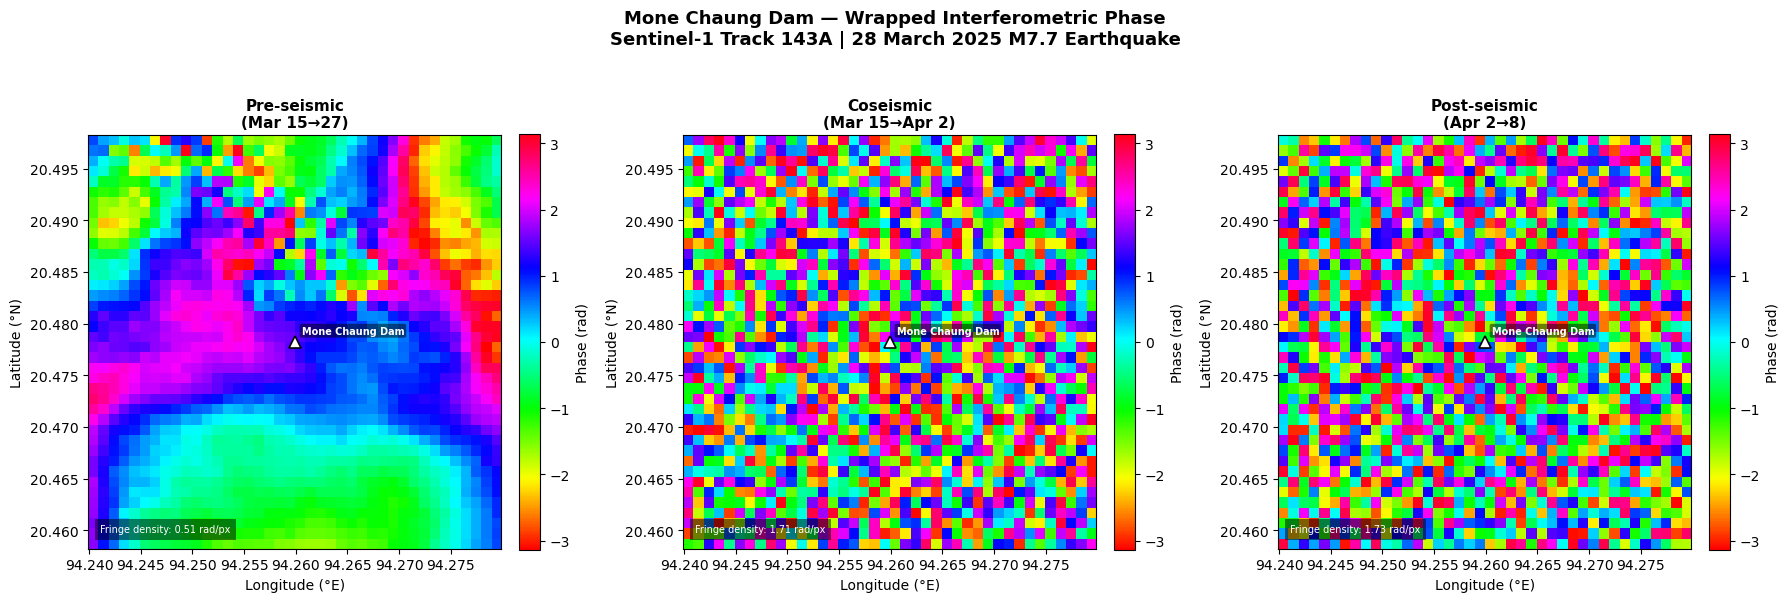

In [33]:
print("\n[1/4] Wrapped phase triplet...")
plot_wrapped_phase_triplet(aoi_bounds)

In [38]:
#print("\n[2/4] Displacement and coherence maps...")
#pair_data = plot_displacement_and_coherence(aoi_bounds, meta)


[3/4] Coherence disturbance map...
✓ Saved: /Users/gbhardwaj1/Library/CloudStorage/OneDrive-WBG/Documents/GitHub/myanmar-economic-monitor/data/SLC_CCL/03_coherence_disturbance.png


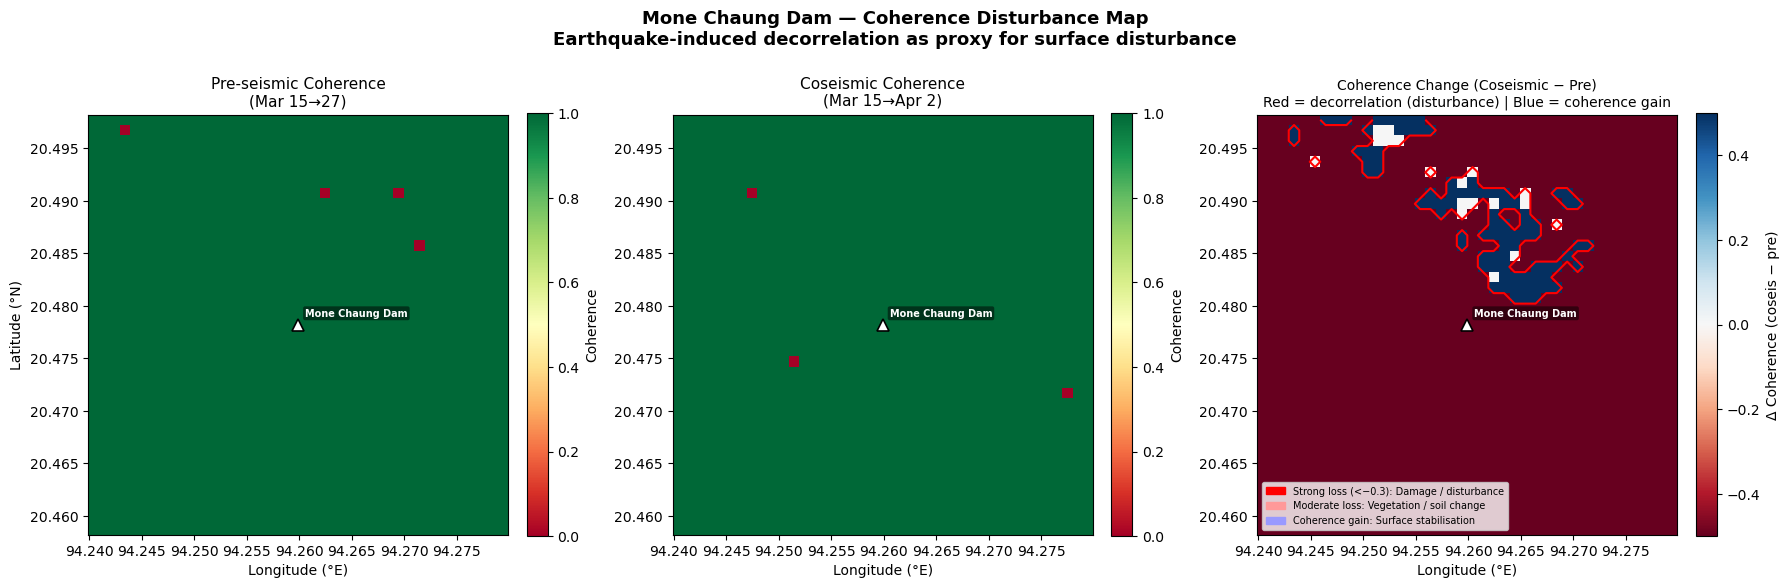


  Dam ROI stats — Coherence change at dam:
    Pixels     : 1249
    Mean       : -56.720
    Std        : 38.730
    Range      : -164.000 to +10.000


In [35]:
print("\n[3/4] Coherence disturbance map...")
plot_coherence_disturbance_map(pair_data, aoi_bounds)


[4/4] Vertical displacement decomposition...
✓ Saved: /Users/gbhardwaj1/Library/CloudStorage/OneDrive-WBG/Documents/GitHub/myanmar-economic-monitor/data/SLC_CCL/04_vertical_displacement_map.png
✓ Saved: /Users/gbhardwaj1/Library/CloudStorage/OneDrive-WBG/Documents/GitHub/myanmar-economic-monitor/data/SLC_CCL/04b_vertical_profile.png


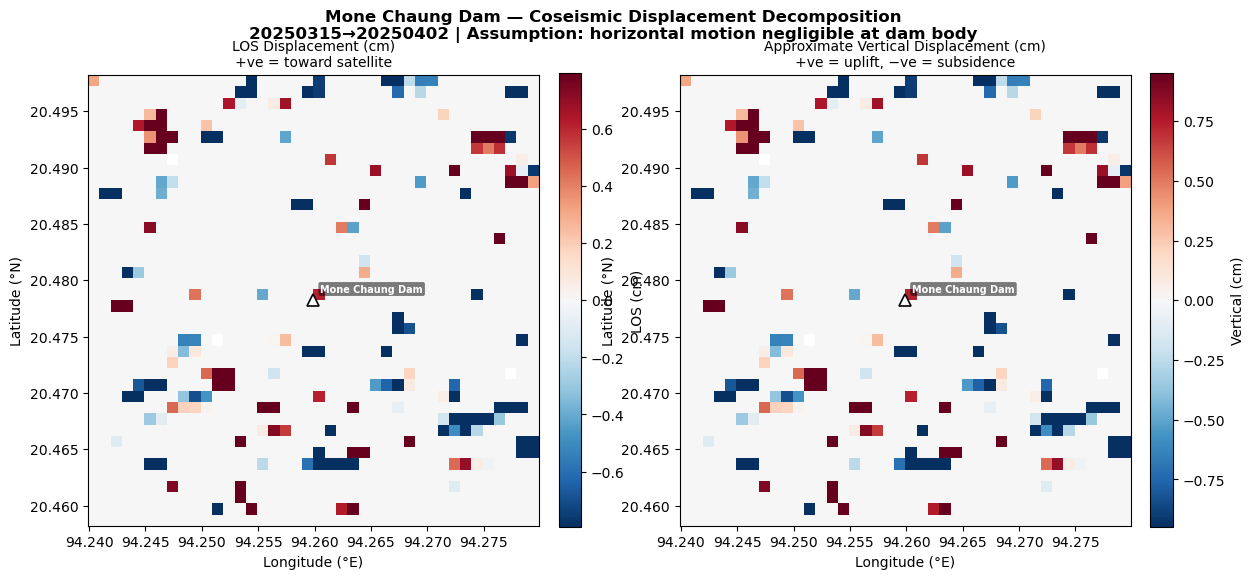

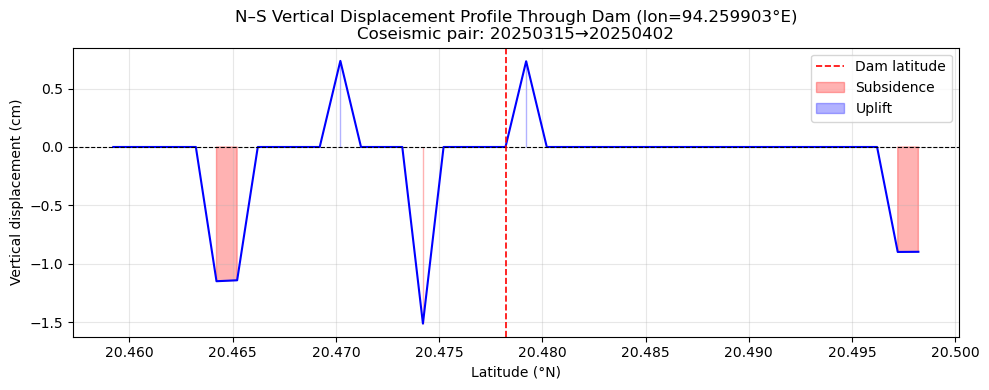


  Dam ROI stats — Vertical displacement at dam:
    Pixels     : 1246
    Mean       : -0.015
    Std        : 0.314
    Range      : -1.773 to +1.718


In [29]:
print("\n[4/4] Vertical displacement decomposition...")
plot_vertical_displacement(pair_data, aoi_bounds)

In [22]:
print_summary_report(pair_data, baselines)


MONE CHAUNG DAM — INSAR EARTHQUAKE IMPACT SUMMARY
  Earthquake : 28 March 2025, M7.7, Sagaing Fault
  Dam        : Mone Chaung, Magway Region, Myanmar
  Frame      : 143A_06849_131313
  Wavelength : 5.6 cm (C-band)
  1 fringe   : 2.8 mm LOS displacement

  Interferogram Baselines:

  Interpretation Guide:
    Coseismic LOS < 0  → ground moved away from satellite
                         (subsidence or E-ward motion on ascending)
    Coseismic LOS > 0  → ground moved toward satellite
                         (uplift or W-ward motion on ascending)
    Coherence drop     → surface disturbance at dam site
    Dense fringes      → high deformation gradient
    Pre-seismic signal → atmospheric noise floor reference

  Next Steps:
    1. Cross-check displacement pattern with USGS ShakeMap
       https://earthquake.usgs.gov/earthquakes/eventpage/
    2. Validate with Sentinel-2 optical (April 2025)
       for visual confirmation of structural change
    3. Run LiCSBAS on full time series for 